# Feature Extraction — HOG Feature Matrices

**Author:** Florian Koenigstorfer

**Goal:** Extract HOG (Histogram of Oriented Gradients) features in two modes:
1. **Optimal configuration** — extract features for train and test splits and save `features_train.npz` and `features_test.npz` for use in model training.
2. **Ablation configurations** — extract features across all cell/block size and orientation-bin combinations (training set only) and save one named `.npz` per configuration, so that the model training notebook can load them directly for CV-based ablation studies.

**Data source:** Preprocessed images from `/data/preprocessed/` and the manifest at `/data/preprocessed_df.csv`, produced by `preprocessing.ipynb`.

## Introduction

HOG features describe local gradient structure by dividing an image into small cells, computing orientation histograms within each cell, and normalising them across overlapping blocks. They are widely used for object detection tasks because they capture shape information while being robust to minor illumination changes.

The optimal configuration (`pixels_per_cell=(8,8)`, `cells_per_block=(3,3)`, `orientations=11`, `block_norm="L1"`) was selected based on prior experimentation. Sections 4 and 5 generate feature matrices for all ablation configurations so that the model training notebook can perform a systematic cross-validation study without re-running this notebook.

---
## Section 0 — Setup & Imports

In [1]:
%matplotlib inline

import os
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import hog
from tqdm.notebook import tqdm

sys.path.insert(0, "../src")
from feature_extraction import (
    extract_hog_features,
    build_feature_matrix,
    save_feature_matrix,
    load_feature_matrix,
    make_ablation_npz_name,
)

# --- Constants ---
PREPROCESSED_DF_PATH = "../data/preprocessed_df.csv"
FEATURES_DIR         = "../data"
FEATURES_TRAIN_PATH  = "../data/features_train.npz"
FEATURES_TEST_PATH   = "../data/features_test.npz"

ORIENTATIONS     = 11
PIXELS_PER_CELL  = (8, 8)
CELLS_PER_BLOCK  = (3, 3)
BLOCK_NORM       = "L1"

HOG_PARAMS = {
    "orientations":    ORIENTATIONS,
    "pixels_per_cell": PIXELS_PER_CELL,
    "cells_per_block": CELLS_PER_BLOCK,
    "block_norm":      BLOCK_NORM,
}

# --- Load manifest ---
if not os.path.exists(PREPROCESSED_DF_PATH):
    raise FileNotFoundError(
        f"Manifest not found at '{PREPROCESSED_DF_PATH}'. "
        "Please run preprocessing.ipynb first to generate the preprocessed images and manifest."
    )

preprocessed_df = pd.read_csv(PREPROCESSED_DF_PATH)
print(f"Loaded manifest: {len(preprocessed_df):,} rows")
preprocessed_df.head()

Loaded manifest: 10,024 rows


,original_filepath,output_filepath,split,label,rotation,width,height
0,../data/Train/Positives/0882100000000118.png,../data/preprocessed/Train/Positives/088210000...,train,positive,0,75,75
1,../data/Train/Positives/0882100000000118.png,../data/preprocessed/Train/Positives/088210000...,train,positive,90,75,75
2,../data/Train/Positives/0882100000000118.png,../data/preprocessed/Train/Positives/088210000...,train,positive,180,75,75
3,../data/Train/Positives/0882100000000118.png,../data/preprocessed/Train/Positives/088210000...,train,positive,270,75,75
4,../data/Train/Positives/0882100000000200.png,../data/preprocessed/Train/Positives/088210000...,train,positive,0,75,75


---
## Section 1 — Optimal HOG Feature Extraction (Training Set)

In [2]:
train_df = preprocessed_df[preprocessed_df["split"] == "train"].reset_index(drop=True)
print(f"Training samples in manifest: {len(train_df):,}")

X_train, y_train, filepaths_train, groups_train = build_feature_matrix(train_df, HOG_PARAMS)

n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
print(f"\nTraining samples extracted : {len(y_train):,}")
print(f"Feature vector length      : {X_train.shape[1]:,}")
print(f"Class balance              : {n_pos:,} positive / {n_neg:,} negative")
print(f"Unique source images       : {len(set(groups_train)):,}")

save_feature_matrix(X_train, y_train, filepaths_train, groups_train, FEATURES_TRAIN_PATH)
print(f"\nSaved → {FEATURES_TRAIN_PATH}")

Training samples in manifest: 8,072


Extracting HOG features: 100%|██████████| 8072/8072 [00:16<00:00, 478.17it/s]



Training samples extracted : 8,072
Feature vector length      : 4,851
Class balance              : 3,272 positive / 4,800 negative
Unique source images       : 2,018

Saved → ../data/features_train.npz


---
## Section 2 — Optimal HOG Feature Extraction (Test Set)

In [3]:
test_df = preprocessed_df[preprocessed_df["split"] == "test"].reset_index(drop=True)
print(f"Test samples in manifest: {len(test_df):,}")

X_test, y_test, filepaths_test, groups_test = build_feature_matrix(test_df, HOG_PARAMS)

n_pos = int(y_test.sum())
n_neg = len(y_test) - n_pos
print(f"\nTest samples extracted : {len(y_test):,}")
print(f"Feature vector length  : {X_test.shape[1]:,}")
print(f"Class balance          : {n_pos:,} positive / {n_neg:,} negative")
print(f"Unique source images   : {len(set(groups_test)):,}")

save_feature_matrix(X_test, y_test, filepaths_test, groups_test, FEATURES_TEST_PATH)
print(f"\nSaved → {FEATURES_TEST_PATH}")

Test samples in manifest: 1,952


Extracting HOG features: 100%|██████████| 1952/1952 [00:03<00:00, 491.23it/s]



Test samples extracted : 1,952
Feature vector length  : 4,851
Class balance          : 752 positive / 1,200 negative
Unique source images   : 488

Saved → ../data/features_test.npz


---
## Section 3 — HOG Visualisation

One random Positive and one random Negative from the training set are shown side-by-side with their HOG visualisations.

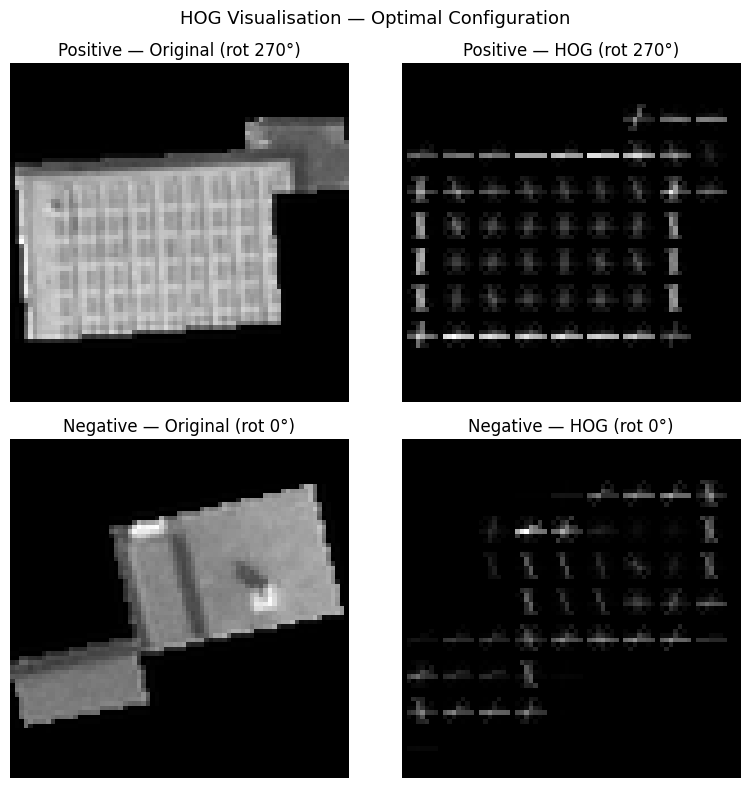

In [4]:
rng = random.Random(42)

pos_rows = train_df[train_df["label"] == "positive"].reset_index(drop=True)
neg_rows = train_df[train_df["label"] == "negative"].reset_index(drop=True)

pos_row = pos_rows.iloc[rng.randint(0, len(pos_rows) - 1)]
neg_row = neg_rows.iloc[rng.randint(0, len(neg_rows) - 1)]

samples = [
    (pos_row, "Positive"),
    (neg_row, "Negative"),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for row_idx, (row, class_name) in enumerate(samples):
    fpath = row["output_filepath"]
    rotation = row["rotation"]

    image = Image.open(fpath)
    arr = np.asarray(image, dtype=np.float64) / 255.0

    _, hog_image = hog(
        arr,
        orientations=ORIENTATIONS,
        pixels_per_cell=PIXELS_PER_CELL,
        cells_per_block=CELLS_PER_BLOCK,
        block_norm=BLOCK_NORM,
        visualize=True,
        feature_vector=True,
    )

    ax_orig = axes[row_idx][0]
    ax_hog  = axes[row_idx][1]

    ax_orig.imshow(arr, cmap="gray")
    ax_orig.set_title(f"{class_name} — Original (rot {rotation}°)")
    ax_orig.axis("off")

    ax_hog.imshow(hog_image, cmap="gray")
    ax_hog.set_title(f"{class_name} — HOG (rot {rotation}°)")
    ax_hog.axis("off")

fig.suptitle("HOG Visualisation — Optimal Configuration", fontsize=13)
fig.tight_layout()

## Section 4 — Ablation Feature Extraction (Cell/Block Size)

This section extracts HOG features for all cell/block size combinations used in the ablation study in the model training notebook. Orientations and block_norm are held fixed at 11 and "L1".
Files are skipped if they already exist, so this section can be re-run safely.

In [5]:
ABLATION_CELL_BLOCK = [
    {"pixels_per_cell": (4,  4),  "cells_per_block": (2, 2)},
    {"pixels_per_cell": (4,  4),  "cells_per_block": (3, 3)},
    {"pixels_per_cell": (4,  4),  "cells_per_block": (4, 4)},
    {"pixels_per_cell": (8,  8),  "cells_per_block": (2, 2)},
    {"pixels_per_cell": (8,  8),  "cells_per_block": (3, 3)},  # optimal
    {"pixels_per_cell": (8,  8),  "cells_per_block": (4, 4)},
    {"pixels_per_cell": (12, 12), "cells_per_block": (2, 2)},
    {"pixels_per_cell": (12, 12), "cells_per_block": (3, 3)},
    {"pixels_per_cell": (12, 12), "cells_per_block": (4, 4)},
    {"pixels_per_cell": (16, 16), "cells_per_block": (2, 2)},
    {"pixels_per_cell": (16, 16), "cells_per_block": (3, 3)},
    {"pixels_per_cell": (16, 16), "cells_per_block": (4, 4)},
]

n_processed = 0
n_skipped = 0

for cfg in tqdm(ABLATION_CELL_BLOCK, desc="Cell/block ablation"):
    ppc = cfg["pixels_per_cell"]
    cpb = cfg["cells_per_block"]
    label = f"ppc={ppc[0]}, cpb={cpb[0]}"

    output_path = make_ablation_npz_name(FEATURES_DIR, ppc, cpb, 11)

    # Skip only if file exists AND already contains the groups key
    if os.path.exists(output_path) and "groups" in np.load(output_path, allow_pickle=False):
        print(f"  SKIP {label} — already up to date: {os.path.basename(output_path)}")
        n_skipped += 1
        continue

    X, y, fps, grp = build_feature_matrix(train_df, {
        "orientations": 11, "pixels_per_cell": ppc, "cells_per_block": cpb, "block_norm": BLOCK_NORM,
    })
    save_feature_matrix(X, y, fps, grp, output_path)
    print(f"  DONE {label} — {len(y):,} samples, {X.shape[1]:,} features → {os.path.basename(output_path)}")
    n_processed += 1

print(f"\nCell/block ablation complete: {n_processed} processed, {n_skipped} skipped")

Cell/block ablation:   0%|          | 0/12 [00:00<?, ?it/s]


Extracting HOG features: 100%|██████████| 8072/8072 [00:47<00:00, 170.64it/s]


  DONE ppc=4, cpb=2 — 8,072 samples, 12,716 features → features_train_ppc4_cpb2_ori11.npz



Extracting HOG features: 100%|██████████| 8072/8072 [00:44<00:00, 182.56it/s]


  DONE ppc=4, cpb=3 — 8,072 samples, 25,344 features → features_train_ppc4_cpb3_ori11.npz


...

  DONE ppc=16, cpb=2 — 8,072 samples, 396 features → features_train_ppc16_cpb2_ori11.npz



Extracting HOG features: 100%|██████████| 8072/8072 [00:10<00:00, 752.51it/s]


  DONE ppc=16, cpb=3 — 8,072 samples, 396 features → features_train_ppc16_cpb3_ori11.npz



Extracting HOG features: 100%|██████████| 8072/8072 [00:09<00:00, 808.23it/s]


  DONE ppc=16, cpb=4 — 8,072 samples, 176 features → features_train_ppc16_cpb4_ori11.npz

Cell/block ablation complete: 12 processed, 0 skipped


---
## Section 5 — Ablation Feature Extraction (Orientation Bins)

This section extracts HOG features for all orientation bin counts used in the ablation study. Cell/block size and `block_norm` are held fixed at `(8, 8)`, `(3, 3)`, and `"L1"`.

Files are skipped if they already exist, so this section can be re-run safely.

In [6]:
ABLATION_ORIENTATIONS = [6, 8, 9, 11, 13, 18]

n_processed = 0
n_skipped = 0

for ori in tqdm(ABLATION_ORIENTATIONS, desc="Orientation ablation"):
    output_path = make_ablation_npz_name(FEATURES_DIR, (8, 8), (3, 3), ori)

    if os.path.exists(output_path) and "groups" in np.load(output_path, allow_pickle=False):
        print(f"  SKIP orientations={ori} — already up to date: {os.path.basename(output_path)}")
        n_skipped += 1
        continue

    X, y, fps, grp = build_feature_matrix(train_df, {
        "orientations": ori, "pixels_per_cell": (8, 8), "cells_per_block": (3, 3), "block_norm": BLOCK_NORM,
    })
    save_feature_matrix(X, y, fps, grp, output_path)
    print(f"  DONE orientations={ori} — {len(y):,} samples, {X.shape[1]:,} features → {os.path.basename(output_path)}")
    n_processed += 1

print(f"\nOrientation ablation complete: {n_processed} processed, {n_skipped} skipped")

Orientation ablation:   0%|          | 0/6 [00:00<?, ?it/s]


Extracting HOG features: 100%|██████████| 8072/8072 [00:15<00:00, 504.97it/s]


  DONE orientations=6 — 8,072 samples, 2,646 features → features_train_ppc8_cpb3_ori6.npz



Extracting HOG features: 100%|██████████| 8072/8072 [00:16<00:00, 496.17it/s]


  DONE orientations=8 — 8,072 samples, 3,528 features → features_train_ppc8_cpb3_ori8.npz


...

  DONE orientations=9 — 8,072 samples, 3,969 features → features_train_ppc8_cpb3_ori9.npz
  SKIP orientations=11 — already up to date: features_train_ppc8_cpb3_ori11.npz



Extracting HOG features: 100%|██████████| 8072/8072 [00:16<00:00, 478.41it/s]


  DONE orientations=13 — 8,072 samples, 5,733 features → features_train_ppc8_cpb3_ori13.npz



Extracting HOG features: 100%|██████████| 8072/8072 [00:18<00:00, 426.12it/s]


  DONE orientations=18 — 8,072 samples, 7,938 features → features_train_ppc8_cpb3_ori18.npz

Orientation ablation complete: 5 processed, 1 skipped


---
## Section 6 — Sanity Checks

This section verifies the saved feature matrices by: (1) reloading the optimal train and test .npz files and asserting that their shapes match the in-memory arrays, (2) counting all-zero feature rows in train and test as a data-quality check, and (3) spot-checking three random non-optimal ablation files to confirm their feature dimensionality differs from the optimal configuration. A summary table is printed at the end.

In [7]:
# --- Reload and verify optimal feature matrices ---
X_train_v, y_train_v, fps_train_v, groups_train_v = load_feature_matrix(FEATURES_TRAIN_PATH)
X_test_v,  y_test_v,  fps_test_v,  groups_test_v  = load_feature_matrix(FEATURES_TEST_PATH)

assert X_train_v.shape == X_train.shape, "Train shape mismatch after reload"
assert X_test_v.shape  == X_test.shape,  "Test shape mismatch after reload"
assert len(y_train_v)  == len(y_train),  "Train label count mismatch"
assert len(y_test_v)   == len(y_test),   "Test label count mismatch"
assert len(groups_train_v) == len(X_train), "Train groups length mismatch"
assert len(groups_test_v)  == len(X_test),  "Test groups length mismatch"
print("Shape verification passed (including groups).")

# --- All-zero row check ---
zero_train = int(np.all(X_train_v == 0, axis=1).sum())
zero_test  = int(np.all(X_test_v  == 0, axis=1).sum())
print(f"All-zero rows — train: {zero_train}, test: {zero_test}")

# --- Spot-check 3 random ablation files ---
optimal_n_features = X_train.shape[1]

ablation_paths = []
for cfg in ABLATION_CELL_BLOCK:
    p = make_ablation_npz_name(FEATURES_DIR, cfg["pixels_per_cell"], cfg["cells_per_block"], 11)
    if os.path.exists(p):
        ablation_paths.append(p)
for ori in ABLATION_ORIENTATIONS:
    p = make_ablation_npz_name(FEATURES_DIR, (8, 8), (3, 3), ori)
    if os.path.exists(p):
        ablation_paths.append(p)

optimal_ablation_path = make_ablation_npz_name(FEATURES_DIR, PIXELS_PER_CELL, CELLS_PER_BLOCK, ORIENTATIONS)
non_optimal_paths = [p for p in ablation_paths if p != optimal_ablation_path]

rng2 = random.Random(42)
spot_paths = rng2.sample(non_optimal_paths, min(3, len(non_optimal_paths)))

confirmed = 0
for p in spot_paths:
    X_ab, _, _, grp_ab = load_feature_matrix(p)
    differs = X_ab.shape[1] != optimal_n_features
    status = "DIFFERS" if differs else "SAME"
    print(f"  {status} — {os.path.basename(p)}: {X_ab.shape[1]} features, {len(set(grp_ab))} unique groups")
    if differs:
        confirmed += 1

# --- Final summary ---
print()
print("=" * 50)
print("FEATURE EXTRACTION SUMMARY")
print("=" * 50)
print(f"  Train samples          : {X_train_v.shape[0]:,}")
print(f"  Test samples           : {X_test_v.shape[0]:,}")
print(f"  Feature dimensions     : {X_train_v.shape[1]:,}")
print(f"  Unique train groups    : {len(set(groups_train_v)):,}")
print(f"  Unique test groups     : {len(set(groups_test_v)):,}")
print(f"  All-zero rows          : {zero_train} (train), {zero_test} (test)")
print(f"  Ablation files confirmed (different length): {confirmed} / {len(spot_paths)}")

Shape verification passed (including groups).
All-zero rows — train: 0, test: 0
  DIFFERS — features_train_ppc8_cpb2_ori11.npz: 2816 features, 2018 unique groups
  DIFFERS — features_train_ppc4_cpb2_ori11.npz: 12716 features, 2018 unique groups
  DIFFERS — features_train_ppc8_cpb3_ori6.npz: 2646 features, 2018 unique groups

FEATURE EXTRACTION SUMMARY
  Train samples          : 8,072
  Test samples           : 1,952
  Feature dimensions     : 4,851
  Unique train groups    : 2,018
  Unique test groups     : 488
  All-zero rows          : 0 (train), 0 (test)
  Ablation files confirmed (different length): 3 / 3
